# EXPERIMENT - 5

Dataset Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

===== INITIAL SVM RESULTS =====
Accuracy: 0.7272727272727273

Confusion Matrix:
 [[81 18]
 [24 31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.82      0.79        99
           1       0.63      0.56      0.60 

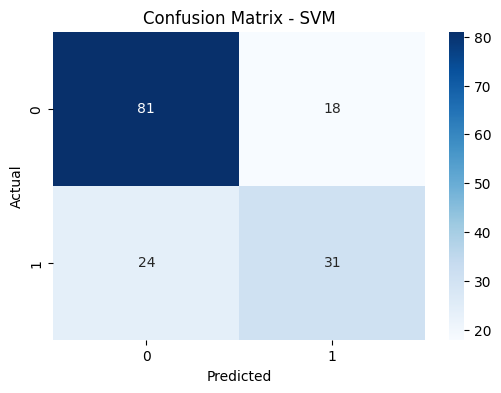


===== HYPERPARAMETER TUNING =====
Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross Validation Score: 0.7687458349993336

===== TUNED SVM RESULTS =====
Accuracy: 0.7337662337662337


===== SVM VISUALIZATION PART =====


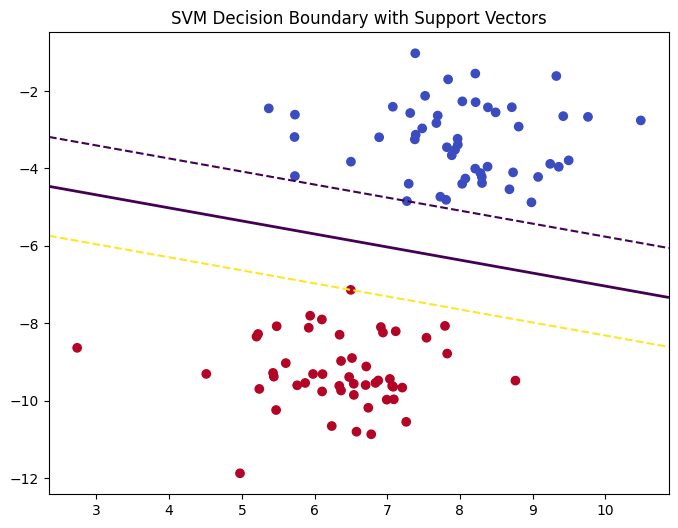

In [3]:
# ============================================================
# PART 1: SVM on Real Dataset (Diabetes Dataset)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import make_blobs

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------
df = pd.read_csv("/content/sample_data/diabetes.csv")  # Upload file in Colab

print("Dataset Shape:", df.shape)
print(df.head())

# ------------------------------------------------------------
# Features & Target
# ------------------------------------------------------------
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# ------------------------------------------------------------
# Feature Scaling (IMPORTANT for SVM)
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# Train-Test Split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# Train Initial SVM Model
# ------------------------------------------------------------
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("\n===== INITIAL SVM RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ------------------------------------------------------------
# Confusion Matrix Heatmap
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------------------------------------------------
# Hyperparameter Tuning
# ------------------------------------------------------------
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.01, 0.1, 1],
    "kernel": ["rbf", "linear"]
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("\n===== HYPERPARAMETER TUNING =====")
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

# Evaluate Tuned Model
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\n===== TUNED SVM RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_best))


# ============================================================
# PART 2: SVM Visualization (Decision Boundary + Support Vectors)
# ============================================================

print("\n\n===== SVM VISUALIZATION PART =====")

# Create 2D synthetic dataset
X_vis, y_vis = make_blobs(n_samples=100, centers=2, random_state=6)

# Train Linear SVM for visualization
model_vis = SVC(kernel='linear', C=1000)
model_vis.fit(X_vis, y_vis)

# Plot data points
plt.figure(figsize=(8,6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap='coolwarm')

# Plot decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model_vis.decision_function(xy).reshape(XX.shape)

# Decision boundary
ax.contour(XX, YY, Z, levels=[0], linewidths=2)

# Margins
ax.contour(XX, YY, Z, levels=[-1, 1], linestyles='--')

# Highlight Support Vectors
ax.scatter(
    model_vis.support_vectors_[:, 0],
    model_vis.support_vectors_[:, 1],
    s=200,
    linewidth=2,
    facecolors='none'
)

plt.title("SVM Decision Boundary with Support Vectors")
plt.show()